In [32]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

In [33]:
# Cargamos los 3 ficheros exportados de PostgreSQL
mediciones = pd.read_csv('mediciones.csv')   # ranging + GPS del sensor, una fila por medición
resultados = pd.read_csv('resultados.csv')   # posición estimada por trilateración RF
anclas = pd.read_csv('anclas_lora.csv')      # posición de las 3 anclas LoRa

mediciones.head()

,id,timestamp,gps_lat,gps_lon,ranging
0,1,2026-08-23 11:06:34.000 +0200,41.159,-1.483,"[{""addr"": 1, ""muestras"": [{""dist"": 8, ""rssi"": ..."
1,2,2026-08-23 11:07:20.000 +0200,41.159,-1.483,"[{""addr"": 1, ""muestras"": [{""dist"": 7, ""rssi"": ..."
2,3,2026-08-23 11:07:59.000 +0200,41.159,-1.483,"[{""addr"": 1, ""muestras"": [{""dist"": 6, ""rssi"": ..."
3,4,2026-08-23 11:08:59.000 +0200,41.159,-1.483,"[{""addr"": 1, ""muestras"": [{""dist"": 5, ""rssi"": ..."
4,5,2026-08-23 11:09:59.000 +0200,41.159,-1.483,"[{""addr"": 1, ""muestras"": [{""dist"": 6, ""rssi"": ..."


In [34]:
# La columna 'ranging' es un JSON guardado como texto. Lo convertimos a dict/lista de Python
mediciones['ranging_parsed'] = mediciones['ranging'].apply(json.loads)
mediciones[['id', 'ranging_parsed']].head()

,id,ranging_parsed
0,1,"[{'addr': 1, 'muestras': [{'dist': 8, 'rssi': ..."
1,2,"[{'addr': 1, 'muestras': [{'dist': 7, 'rssi': ..."
2,3,"[{'addr': 1, 'muestras': [{'dist': 6, 'rssi': ..."
3,4,"[{'addr': 1, 'muestras': [{'dist': 5, 'rssi': ..."
4,5,"[{'addr': 1, 'muestras': [{'dist': 6, 'rssi': ..."


In [35]:
# El CSV trae las 5 pruebas de campo seguidas; aquí las separamos según los rangos de 'id'
limites_bloques = [
    (1, 11, 1),   # punto 1, centro del triángulo
    (12, 22, 2),  # punto 2, cerca del ancla 1
    (23, 34, 3),  # punto 3, cerca del ancla 2
    (35, 46, 4),  # punto 4, cerca del ancla 3
    (47, 58, 5),  # punto 5, fuera del triángulo
]

def asignar_punto(id_):
    for inicio, fin, punto in limites_bloques:
        if inicio <= id_ <= fin:
            return punto
    return None

mediciones['punto'] = mediciones['id'].apply(asignar_punto)
resultados['punto'] = resultados['id'].apply(asignar_punto)

# Comprobación: deberían salir 11, 11, 12, 12, 12 mediciones por punto
mediciones['punto'].value_counts().sort_index()

punto
1    11
2    11
3    12
4    12
5    12
Name: count, dtype: int64

In [36]:
# Ground truth de cada punto:
# - dist_real_anclaX: distancias medidas con cinta métrica, referencia fiable
# - lat_ojo/lon_ojo: posición estimada a ojo con el móvil, solo de apoyo, no se usa como referencia principal
referencia = pd.DataFrame({
    'punto': [1, 2, 3, 4, 5],
    'lat_ojo': [
        41.159031,
        41.159021,
        41.158953,
        41.159063,
        41.158942,
    ],
    'lon_ojo': [
        -1.483102,
        -1.483184,
        -1.483064,
        -1.483067,
        -1.483177,
    ],
    'dist_real_ancla1': [9, 4, 13, 14, 8],
    'dist_real_ancla2': [10, 13, 4, 13, 8],
    'dist_real_ancla3': [7, 11, 12, 3, 16],
})

referencia

,punto,lat_ojo,lon_ojo,dist_real_ancla1,dist_real_ancla2,dist_real_ancla3
0,1,41.159,-1.483,9,10,7
1,2,41.159,-1.483,4,13,11
2,3,41.159,-1.483,13,4,12
3,4,41.159,-1.483,14,13,3
4,5,41.159,-1.483,8,8,16


In [37]:
# Funciones auxiliares para cálculos geográficos

def haversine(lat1, lon1, lat2, lon2):
    """Distancia en metros entre dos puntos GPS (lat/lon en grados decimales)."""
    R = 6371000  # radio medio de la Tierra en metros
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def proyectar_xy(lat, lon, lat_ref, lon_ref):
    """Convierte lat/lon a coordenadas locales x (este) / y (norte) en metros,
    tomando (lat_ref, lon_ref) como origen del plano."""
    x = (lon - lon_ref) * np.cos(np.radians(lat_ref)) * 111320.0
    y = (lat - lat_ref) * 111320.0
    return x, y

In [38]:
def trilaterar_xy(xs, ys, dists):
    """Mínimos cuadrados de trilateración en el plano local (mismo método que
    usa la función SQL de Postgres), tomando el primer punto de la lista como referencia."""
    x_ref, y_ref, d_ref = xs[0], ys[0], dists[0]
    Sxx = Sxy = Syy = Sxc = Syc = 0.0
    for i in range(1, len(dists)):
        xi, yi, di = xs[i], ys[i], dists[i]
        a = 2 * (xi - x_ref)
        b = 2 * (yi - y_ref)
        c = d_ref**2 - di**2 - x_ref**2 + xi**2 - y_ref**2 + yi**2
        Sxx += a*a; Sxy += a*b; Syy += b*b; Sxc += a*c; Syc += b*c
    det = Sxx * Syy - Sxy * Sxy
    if det == 0:
        return None
    x_est = (Sxc * Syy - Sxy * Syc) / det
    y_est = (Sxx * Syc - Sxc * Sxy) / det
    return x_est, y_est

def xy_a_latlon(x, y, lat_ref, lon_ref):
    lat = lat_ref + y / 111320.0
    lon = lon_ref + x / (111320.0 * np.cos(np.radians(lat_ref)))
    return lat, lon

# Coordenadas locales de las 3 anclas, con ancla_01 como origen del plano
lat_ref = anclas.loc[anclas['identificador'] == '0x00000001', 'lat'].values[0]
lon_ref = anclas.loc[anclas['identificador'] == '0x00000001', 'lon'].values[0]
anclas['x'], anclas['y'] = proyectar_xy(anclas['lat'], anclas['lon'], lat_ref, lon_ref)
xs_anclas = anclas['x'].tolist()
ys_anclas = anclas['y'].tolist()

# Para cada punto, trilateramos su posición a partir de las 3 distancias de cinta métrica
referencia['lat_real'] = np.nan
referencia['lon_real'] = np.nan
for i, fila in referencia.iterrows():
    dists = [fila['dist_real_ancla1'], fila['dist_real_ancla2'], fila['dist_real_ancla3']]
    resultado = trilaterar_xy(xs_anclas, ys_anclas, dists)
    if resultado:
        x_est, y_est = resultado
        lat_est, lon_est = xy_a_latlon(x_est, y_est, lat_ref, lon_ref)
        referencia.loc[i, 'lat_real'] = lat_est
        referencia.loc[i, 'lon_real'] = lon_est

referencia

,punto,lat_ojo,lon_ojo,dist_real_ancla1,dist_real_ancla2,dist_real_ancla3,lat_real,lon_real
0,1,41.159,-1.483,9,10,7,41.159,-1.483
1,2,41.159,-1.483,4,13,11,41.159,-1.483
2,3,41.159,-1.483,13,4,12,41.159,-1.483
3,4,41.159,-1.483,14,13,3,41.159,-1.483
4,5,41.159,-1.483,8,8,16,41.159,-1.483


In [39]:
# Cada medición trae 3 anclas x 5 muestras = 15 lecturas individuales.
# Las "aplanamos" a una fila por lectura, para poder analizarlas con pandas.
filas = []
for _, fila in mediciones.iterrows():
    for ancla in fila['ranging_parsed']:
        addr = ancla['addr']
        for muestra in ancla['muestras']:
            filas.append({
                'id': fila['id'],
                'punto': fila['punto'],
                'addr': addr,
                'dist_medida': muestra['dist'],
                'rssi': muestra['rssi'],
            })

ranging_largo = pd.DataFrame(filas)
ranging_largo.head(10)

,id,punto,addr,dist_medida,rssi
0,1,1,1,8,-68
1,1,1,1,2,-68
2,1,1,1,6,-68
3,1,1,1,6,-68
4,1,1,1,7,-68
5,1,1,2,17,-73
6,1,1,2,17,-73
7,1,1,2,18,-73
8,1,1,2,12,-73
9,1,1,2,17,-73


In [40]:
# 'referencia' está en formato ancho (una columna por ancla). Lo paso a formato largo (una fila por punto-ancla) para poder cruzarlo con ranging_largo
referencia_larga = referencia.melt(
    id_vars=['punto'],
    value_vars=['dist_real_ancla1', 'dist_real_ancla2', 'dist_real_ancla3'],
    var_name='ancla_ref',
    value_name='dist_real',
)
referencia_larga['addr'] = referencia_larga['ancla_ref'].str.extract(r'(\d)').astype(int)

# Cruce: cada lectura individual se queda con la distancia real de su punto/ancla
ranging_con_ref = ranging_largo.merge(
    referencia_larga[['punto', 'addr', 'dist_real']],
    on=['punto', 'addr'],
    how='left',
)

# Diferencia medida - real: positivo = sobreestima, negativo = subestima
ranging_con_ref['error_dist'] = ranging_con_ref['dist_medida'] - ranging_con_ref['dist_real']

ranging_con_ref.head(10)

,id,punto,addr,dist_medida,rssi,dist_real,error_dist
0,1,1,1,8,-68,9,-1
1,1,1,1,2,-68,9,-7
2,1,1,1,6,-68,9,-3
3,1,1,1,6,-68,9,-3
4,1,1,1,7,-68,9,-2
5,1,1,2,17,-73,10,7
6,1,1,2,17,-73,10,7
7,1,1,2,18,-73,10,8
8,1,1,2,12,-73,10,2
9,1,1,2,17,-73,10,7


In [41]:
# Sesgo medio (sistemático) y dispersión (SD) del error, por combinación punto-ancla
resumen_error_ranging = ranging_con_ref.groupby(['punto', 'addr']).agg(
    dist_real=('dist_real', 'first'),
    dist_media_medida=('dist_medida', 'mean'),
    error_medio=('error_dist', 'mean'),
    error_sd=('error_dist', 'std'),
    n=('error_dist', 'count'),
).reset_index()

resumen_error_ranging


,punto,addr,dist_real,dist_media_medida,error_medio,error_sd,n
0,1,1,9,4.473,-4.527,1.904,55
1,1,2,10,16.527,6.527,1.597,55
2,1,3,7,7.509,0.509,1.894,55
3,2,1,4,4.691,0.691,2.017,55
4,2,2,13,5.182,-7.818,2.366,55
5,2,3,11,16.727,5.727,2.505,55
6,3,1,13,11.833,-1.167,2.001,60
7,3,2,4,2.700,-1.300,1.710,60
8,3,3,12,12.933,0.933,1.812,60
9,4,1,14,13.733,-0.267,2.393,60


In [42]:
# Tabla resumen de error medio por punto y ancla, es decir, la distancia media que se sobreestima o subestima respecto a la cinta métrica.

tabla_15 = resumen_error_ranging.pivot(index='punto', columns='addr', values='error_medio')
tabla_15.columns = [f'Ancla {c}' for c in tabla_15.columns]
tabla_15 = tabla_15.round(2).reset_index()

tabla_15.style.hide(axis='index')

punto,Ancla 1,Ancla 2,Ancla 3
1,-4.530000,6.530000,0.510000
2,0.690000,-7.820000,5.730000
3,-1.170000,-1.300000,0.930000
4,-0.270000,-0.620000,-2.930000
5,-1.700000,-0.600000,22.980000


In [43]:
# Unimos cada estimación de posición (lat_estimada/lon_estimada) con la referencia de su punto (ya trilaterada a partir de las distancias de cinta métrica)
resultados_con_ref = resultados.merge(
    referencia[['punto', 'lat_real', 'lon_real']],
    on='punto',
    how='left',
)

# Distancia entre la posición estimada por el sistema y la posición de referencia
resultados_con_ref['error_posicion_m'] = haversine(
    resultados_con_ref['lat_estimada'], resultados_con_ref['lon_estimada'],
    resultados_con_ref['lat_real'], resultados_con_ref['lon_real'],
)

resultados_con_ref[['id', 'punto', 'lat_estimada', 'lon_estimada', 'error_posicion_m', 'hdop', 'residual_medio']].head(15)

,id,punto,lat_estimada,lon_estimada,error_posicion_m,hdop,residual_medio
0,1,1,41.159,-1.483,8.079,1.156,1.605
1,2,1,41.159,-1.483,8.079,1.156,1.605
2,3,1,41.159,-1.483,9.674,1.182,2.742
3,4,1,41.159,-1.483,8.394,1.158,2.108
4,5,1,41.159,-1.483,8.394,1.158,2.108
5,6,1,41.159,-1.483,7.428,1.158,1.585
6,7,1,41.159,-1.483,8.293,1.157,1.601
7,8,1,41.159,-1.483,8.394,1.158,2.108
8,9,1,41.159,-1.483,9.929,1.189,3.234
9,10,1,41.159,-1.483,7.957,1.155,1.093


In [44]:
# Error medio/máx/mín de posición por punto, junto con los indicadores propios
# del sistema (hdop, residual_medio) para ver si "avisan" cuando el error es alto
resumen_posicion = resultados_con_ref.groupby('punto').agg(
    error_medio_m=('error_posicion_m', 'mean'),
    error_max_m=('error_posicion_m', 'max'),
    error_min_m=('error_posicion_m', 'min'),
    hdop_medio=('hdop', 'mean'),
    residual_medio_medio=('residual_medio', 'mean'),
    n_estimaciones=('error_posicion_m', 'count'),  # excluye NaN (mediciones con solo 2 anclas)
).reset_index()

resumen_posicion

,punto,error_medio_m,error_max_m,error_min_m,hdop_medio,residual_medio_medio,n_estimaciones
0,1,8.347,9.929,7.202,1.162,1.945,11
1,2,10.282,13.570,7.367,1.186,3.036,11
2,3,2.351,5.794,0.923,1.320,0.841,12
3,4,3.531,6.110,0.780,1.231,1.934,12
4,5,49.072,65.596,33.519,4.984,38.233,12


In [45]:
# Comparamos la posición a ojo con el móvil (lat_ojo/lon_ojo) contra la referencia
# por cinta métrica (lat_real/lon_real), solo para documentar por qué se descarta
# la posición a ojo como referencia principal (ver hallazgo del punto 3).
referencia['diff_ojo_vs_cinta_m'] = haversine(
    referencia['lat_ojo'], referencia['lon_ojo'],
    referencia['lat_real'], referencia['lon_real'],
)

referencia[['punto', 'lat_ojo', 'lon_ojo', 'lat_real', 'lon_real', 'diff_ojo_vs_cinta_m']]

,punto,lat_ojo,lon_ojo,lat_real,lon_real,diff_ojo_vs_cinta_m
0,1,41.159,-1.483,41.159,-1.483,2.907
1,2,41.159,-1.483,41.159,-1.483,1.279
2,3,41.159,-1.483,41.159,-1.483,1.553
3,4,41.159,-1.483,41.159,-1.483,3.477
4,5,41.159,-1.483,41.159,-1.483,0.582


In [46]:
# Cruzamos cada medición (con su propio GPS del sensor) con la referencia de su punto
mediciones_con_ref = mediciones.merge(
    referencia[['punto', 'lat_real', 'lon_real']],
    on='punto',
    how='left',
)

# Distancia entre el GPS del sensor en esa lectura y la referencia por cinta métrica
mediciones_con_ref['error_gps_m'] = haversine(
    mediciones_con_ref['gps_lat'], mediciones_con_ref['gps_lon'],
    mediciones_con_ref['lat_real'], mediciones_con_ref['lon_real'],
)

mediciones_con_ref[['id', 'punto', 'gps_lat', 'gps_lon', 'error_gps_m']].head(10)

,id,punto,gps_lat,gps_lon,error_gps_m
0,1,1,41.159,-1.483,2.705
1,2,1,41.159,-1.483,2.788
2,3,1,41.159,-1.483,1.939
3,4,1,41.159,-1.483,3.364
4,5,1,41.159,-1.483,1.194
5,6,1,41.159,-1.483,1.669
6,7,1,41.159,-1.483,0.244
7,8,1,41.159,-1.483,3.405
8,9,1,41.159,-1.483,1.861
9,10,1,41.159,-1.483,2.009


In [47]:
# Para cada punto, calculamos el centroide (posición media) de las ~11-12 lecturas
# de GPS del sensor, y la distancia media de cada lectura a ese centroide.
# Esto mide qué tan repetible es el propio GPS, independientemente de si la
# referencia (cinta métrica / a ojo) es correcta o no.
centroides = mediciones_con_ref.groupby('punto')[['gps_lat', 'gps_lon']].mean()
centroides.columns = ['gps_lat_centroide', 'gps_lon_centroide']

mediciones_con_ref = mediciones_con_ref.merge(centroides, on='punto', how='left')
mediciones_con_ref['dispersion_gps_m'] = haversine(
    mediciones_con_ref['gps_lat'], mediciones_con_ref['gps_lon'],
    mediciones_con_ref['gps_lat_centroide'], mediciones_con_ref['gps_lon_centroide'],
)

resumen_gps = mediciones_con_ref.groupby('punto').agg(
    error_medio_gps_m=('error_gps_m', 'mean'),
    dispersion_media_gps_m=('dispersion_gps_m', 'mean'),
    n=('error_gps_m', 'count'),
).reset_index()

resumen_gps

,punto,error_medio_gps_m,dispersion_media_gps_m,n
0,1,2.310,1.510,11
1,2,4.150,4.592,11
2,3,2.930,2.064,12
3,4,3.974,1.669,12
4,5,3.372,3.165,12


In [48]:
# Juntamos en una sola tabla el error medio de las dos fuentes de posición del
# logger, ambas comparadas contra la misma referencia (cinta métrica)
comparacion_gps_rf = resumen_gps[['punto', 'error_medio_gps_m', 'dispersion_media_gps_m']].merge(
    resumen_posicion[['punto', 'error_medio_m']].rename(columns={'error_medio_m': 'error_medio_rf_m'}),
    on='punto',
)

comparacion_gps_rf

,punto,error_medio_gps_m,dispersion_media_gps_m,error_medio_rf_m
0,1,2.310,1.510,8.347
1,2,4.150,4.592,10.282
2,3,2.930,2.064,2.351
3,4,3.974,1.669,3.531
4,5,3.372,3.165,49.072


In [49]:
# Proyectamos la referencia y las estimaciones de posición (RF y GPS del sensor)
# al mismo plano local x/y que ya usamos para las anclas (celda 7)
referencia['x_real'], referencia['y_real'] = proyectar_xy(referencia['lat_real'], referencia['lon_real'], lat_ref, lon_ref)
resultados_con_ref['x_rf'], resultados_con_ref['y_rf'] = proyectar_xy(
    resultados_con_ref['lat_estimada'], resultados_con_ref['lon_estimada'], lat_ref, lon_ref
)
mediciones_con_ref['x_gps'], mediciones_con_ref['y_gps'] = proyectar_xy(
    mediciones_con_ref['gps_lat'], mediciones_con_ref['gps_lon'], lat_ref, lon_ref
)

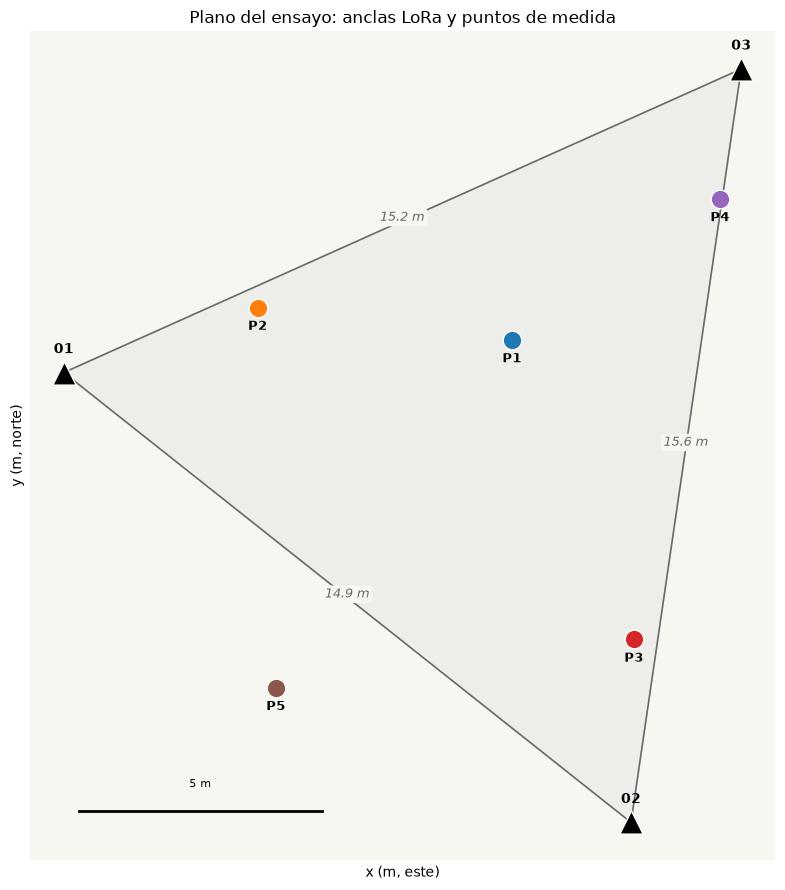

In [50]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_facecolor('#f7f7f2')

# Triángulo relleno suave
tri_x = list(anclas['x']) + [anclas['x'].iloc[0]]
tri_y = list(anclas['y']) + [anclas['y'].iloc[0]]
ax.fill(tri_x, tri_y, color='gray', alpha=0.08)
ax.plot(tri_x, tri_y, '-', color='dimgray', lw=1.2)

# Anclas
ax.scatter(anclas['x'], anclas['y'], marker='^', s=280, color='black', zorder=5, edgecolor='white', linewidth=1)
for _, a in anclas.iterrows():
    ax.annotate(a['identificador'][-2:], (a['x'], a['y']), textcoords="offset points", xytext=(0, 14), fontsize=10, fontweight='bold', ha='center')

# Cotas entre anclas
pares = [(0, 1), (1, 2), (2, 0)]
for i, j in pares:
    x1, y1 = anclas['x'].iloc[i], anclas['y'].iloc[i]
    x2, y2 = anclas['x'].iloc[j], anclas['y'].iloc[j]
    dist_anclas = haversine(anclas['lat'].iloc[i], anclas['lon'].iloc[i], anclas['lat'].iloc[j], anclas['lon'].iloc[j])
    ax.annotate(f'{dist_anclas:.1f} m', ((x1 + x2) / 2, (y1 + y2) / 2), fontsize=9, color='dimgray',  ha='center', style='italic', bbox=dict(boxstyle='round,pad=0.2', fc='#f7f7f2', ec='none'))

# Puntos de ensayo
colores = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:red', 4: 'tab:purple', 5: 'tab:brown'}
for _, p in referencia.iterrows():
    punto = int(p['punto'])
    ax.scatter(p['x_real'], p['y_real'], marker='o', s=180, color=colores[punto], zorder=5, edgecolor='white', linewidth=1)
    ax.annotate(f"P{punto}", (p['x_real'], p['y_real']), textcoords="offset points", xytext=(0, -16), fontsize=9, fontweight='bold', ha='center')

# Barra de escala (5 m)
x0, y0 = ax.get_xlim()[0] + 1, ax.get_ylim()[0] + 1
ax.plot([x0, x0 + 5], [y0, y0], color='black', lw=2)
ax.annotate('5 m', (x0 + 2.5, y0 + 0.5), fontsize=8, ha='center')

ax.set_xlabel('x (m, este)')
ax.set_ylabel('y (m, norte)')
ax.set_title('Plano del ensayo: anclas LoRa y puntos de medida')
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

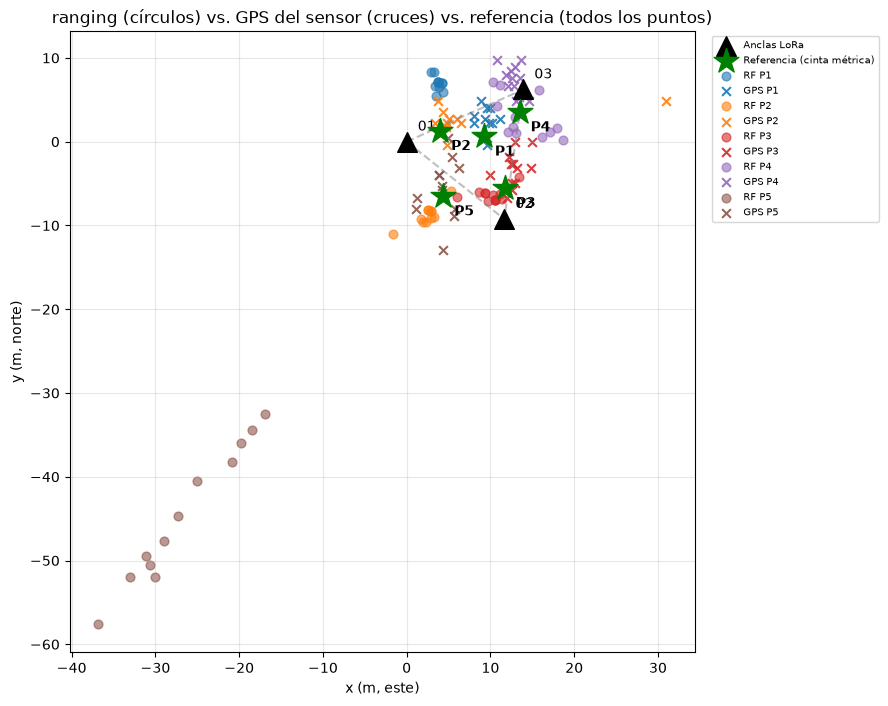

In [51]:
def graficar_posiciones(puntos_incluidos, titulo, zoom_margen=None):
    """
    zoom_margen: si se indica (en metros), recorta los ejes alrededor de los
    puntos incluidos con ese margen, en vez de mostrar todo el triángulo.
    """
    fig, ax = plt.subplots(figsize=(9, 9))

    # Anclas y triángulo
    ax.scatter(anclas['x'], anclas['y'], marker='^', s=200, color='black', label='Anclas LoRa', zorder=5)
    for _, a in anclas.iterrows():
        ax.annotate(a['identificador'][-2:], (a['x'], a['y']), textcoords="offset points", xytext=(8, 8))
    tri_x = list(anclas['x']) + [anclas['x'].iloc[0]]
    tri_y = list(anclas['y']) + [anclas['y'].iloc[0]]
    ax.plot(tri_x, tri_y, '--', color='gray', alpha=0.5)

    # Posición de referencia (cinta métrica)
    ref_sub = referencia[referencia['punto'].isin(puntos_incluidos)]
    ax.scatter(ref_sub['x_real'], ref_sub['y_real'], marker='*', s=350, color='green', label='Referencia (cinta métrica)', zorder=6)
    for _, p in ref_sub.iterrows():
        ax.annotate(f"P{int(p['punto'])}", (p['x_real'], p['y_real']), textcoords="offset points", xytext=(8, -14), fontweight='bold')

    colores = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:red', 4: 'tab:purple', 5: 'tab:brown'}
    xs_todos, ys_todos = [], []
    for punto in puntos_incluidos:
        color = colores[punto]
        sub_rf = resultados_con_ref[resultados_con_ref['punto'] == punto]
        ax.scatter(sub_rf['x_rf'], sub_rf['y_rf'], color=color, alpha=0.6, s=40, marker='o', label=f'RF P{punto}')
        sub_gps = mediciones_con_ref[mediciones_con_ref['punto'] == punto]
        ax.scatter(sub_gps['x_gps'], sub_gps['y_gps'], color=color, alpha=0.9, s=40, marker='x', label=f'GPS P{punto}')
        xs_todos += list(sub_rf['x_rf']) + list(sub_gps['x_gps']) + [ref_sub.loc[ref_sub['punto'] == punto, 'x_real'].values[0]]
        ys_todos += list(sub_rf['y_rf']) + list(sub_gps['y_gps']) + [ref_sub.loc[ref_sub['punto'] == punto, 'y_real'].values[0]]

    # Si se pide zoom, recortamos los ejes al rango de los puntos + margen,
    # en vez de dejar que abarque todo el triángulo de anclas
    if zoom_margen is not None:
        ax.set_xlim(min(xs_todos) - zoom_margen, max(xs_todos) + zoom_margen)
        ax.set_ylim(min(ys_todos) - zoom_margen, max(ys_todos) + zoom_margen)

    ax.set_xlabel('x (m, este)')
    ax.set_ylabel('y (m, norte)')
    ax.set_title(titulo)
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Mapa completo, sin zoom
graficar_posiciones([1, 2, 3, 4, 5], 'ranging (círculos) vs. GPS del sensor (cruces) vs. referencia (todos los puntos)')

# Mapa sin punto 5, con zoom (margen de 3 m alrededor de los puntos)
# graficar_posiciones([1, 2, 3, 4], 'ranging (círculos) vs. GPS del sensor (cruces) vs. referencia (sin punto 5)', zoom_margen=3)

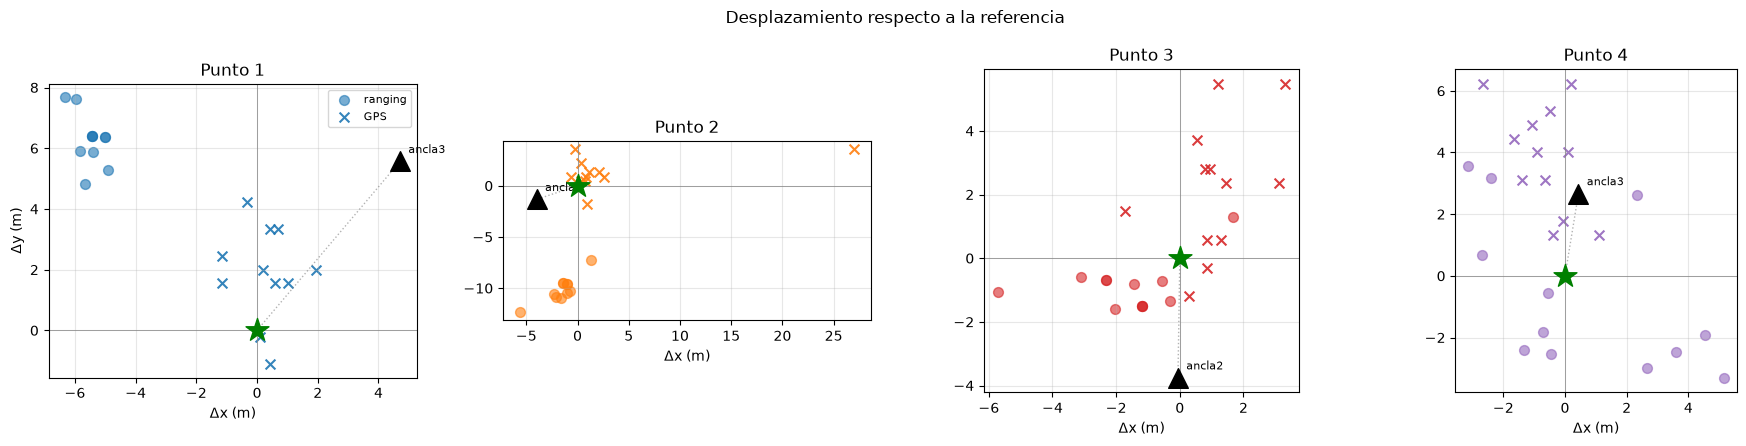

In [52]:
def graficar_error_relativo(puntos_incluidos, titulo):
    n = len(puntos_incluidos)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
    if n == 1:
        axes = [axes]

    colores = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:red', 4: 'tab:purple', 5: 'tab:brown'}
    dist_cols = {1: 'dist_real_ancla1', 2: 'dist_real_ancla2', 3: 'dist_real_ancla3'}

    for ax, punto in zip(axes, puntos_incluidos):
        color = colores[punto]
        fila_ref = referencia[referencia['punto'] == punto].iloc[0]
        x_ref, y_ref = fila_ref['x_real'], fila_ref['y_real']

        sub_rf = resultados_con_ref[resultados_con_ref['punto'] == punto]
        ax.scatter(sub_rf['x_rf'] - x_ref, sub_rf['y_rf'] - y_ref,
                   color=color, alpha=0.6, s=50, marker='o', label='ranging')

        sub_gps = mediciones_con_ref[mediciones_con_ref['punto'] == punto]
        ax.scatter(sub_gps['x_gps'] - x_ref, sub_gps['y_gps'] - y_ref, color=color, alpha=0.9, s=50, marker='x', label='GPS')

        ax.scatter(0, 0, marker='*', s=300, color='green', zorder=5)

        # Ancla más cercana a este punto, según las distancias de cinta métrica,
        # dibujada en su posición relativa a la referencia del punto
        addr_cercana = min([1, 2, 3], key=lambda a: fila_ref[dist_cols[a]])
        ancla_fila = anclas[anclas['identificador'] == f'0x0000000{addr_cercana}'].iloc[0]
        x_ancla_rel = ancla_fila['x'] - x_ref
        y_ancla_rel = ancla_fila['y'] - y_ref
        ax.scatter(x_ancla_rel, y_ancla_rel, marker='^', s=200, color='black', zorder=5)
        ax.annotate(f'ancla{addr_cercana}', (x_ancla_rel, y_ancla_rel),
                    textcoords="offset points", xytext=(6, 6), fontsize=8)
        ax.plot([0, x_ancla_rel], [0, y_ancla_rel], ':', color='gray', lw=1, alpha=0.6)

        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        ax.set_title(f'Punto {punto}')
        ax.set_xlabel('Δx (m)')
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Δy (m)')
    axes[0].legend(fontsize=8, loc='upper right')
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

graficar_error_relativo([1, 2, 3, 4], 'Desplazamiento respecto a la referencia')

In [53]:
# Tabla final: error de posición (RF y GPS), indicadores del sistema (hdop, residual) y desglose de ranging (sesgo/dispersión de cada ancla), todo por punto
resumen_final = resumen_posicion.merge(
    resumen_gps[['punto', 'error_medio_gps_m', 'dispersion_media_gps_m']],
    on='punto',
).rename(columns={'error_medio_m': 'error_medio_rf_m'})

resumen_final.style.format({
    'error_medio_rf_m': '{:.2f}',
    'error_max_m': '{:.2f}',
    'error_min_m': '{:.2f}',
    'hdop_medio': '{:.2f}',
    'residual_medio_m': '{:.2f}',
    'error_medio_gps_m': '{:.2f}',
    'dispersion_media_gps_m': '{:.2f}',
}).hide(axis='index')

punto,error_medio_rf_m,error_max_m,error_min_m,hdop_medio,residual_medio_medio,n_estimaciones,error_medio_gps_m,dispersion_media_gps_m
1,8.35,9.93,7.20,1.16,1.945307,11,2.31,1.51
2,10.28,13.57,7.37,1.19,3.036213,11,4.15,4.59
3,2.35,5.79,0.92,1.32,0.841074,12,2.93,2.06
4,3.53,6.11,0.78,1.23,1.934089,12,3.97,1.67
5,49.07,65.60,33.52,4.98,38.232961,12,3.37,3.16


In [54]:
tabla_anclas = anclas[['identificador', 'lat', 'lon']].copy()
tabla_anclas.columns = ['Ancla', 'Latitud', 'Longitud']

tabla_anclas.style.format({'Latitud': '{:.6f}', 'Longitud': '{:.6f}'}).hide(axis='index')

Ancla,Latitud,Longitud
0x00000001,41.159000,-1.483222
0x00000002,41.158917,-1.483083
0x00000003,41.159056,-1.483056


In [55]:
tabla_puntos = referencia[['punto', 'lat_ojo', 'lon_ojo',
                            'dist_real_ancla1', 'dist_real_ancla2', 'dist_real_ancla3']].copy()
tabla_puntos.columns = ['Punto', 'Latitud (GPS)', 'Longitud (GPS)',
                         'Dist. ancla 1 (m)', 'Dist. ancla 2 (m)', 'Dist. ancla 3 (m)']

tabla_puntos.style.format({
    'Latitud (GPS)': '{:.6f}',
    'Longitud (GPS)': '{:.6f}',
    'Dist. ancla 1 (m)': '{:.0f}',
    'Dist. ancla 2 (m)': '{:.0f}',
    'Dist. ancla 3 (m)': '{:.0f}',
}).hide(axis='index')

Punto,Latitud (GPS),Longitud (GPS),Dist. ancla 1 (m),Dist. ancla 2 (m),Dist. ancla 3 (m)
1,41.159031,-1.483102,9,10,7
2,41.159021,-1.483184,4,13,11
3,41.158953,-1.483064,13,4,12
4,41.159063,-1.483067,14,13,3
5,41.158942,-1.483177,8,8,16


In [56]:
# Distancia media (de la mediana) por punto y ancla, en formato ancho
dist_media_ancho = resumen_error_ranging.pivot(index='punto', columns='addr', values='dist_media_medida')
dist_media_ancho.columns = [f'Dist. media ancla {c} (m)' for c in dist_media_ancho.columns]

# Posición media estimada por el sistema (RF), por punto
posicion_rf_media = resultados_con_ref.groupby('punto')[['lat_estimada', 'lon_estimada']].mean()
posicion_rf_media.columns = ['Lat. estimada (media)', 'Lon. estimada (media)']

# Posición media del GPS del sensor, por punto (ya la teníamos como centroide en el bloque 6)
posicion_gps_media = mediciones_con_ref.groupby('punto')[['gps_lat', 'gps_lon']].mean()
posicion_gps_media.columns = ['Lat. GPS (media)', 'Lon. GPS (media)']

tabla_entrada = dist_media_ancho.join(posicion_rf_media).join(posicion_gps_media).reset_index()

tabla_entrada.style.format({
    'Dist. media ancla 1 (m)': '{:.1f}',
    'Dist. media ancla 2 (m)': '{:.1f}',
    'Dist. media ancla 3 (m)': '{:.1f}',
    'Lat. estimada (media)': '{:.6f}',
    'Lon. estimada (media)': '{:.6f}',
    'Lat. GPS (media)': '{:.6f}',
    'Lon. GPS (media)': '{:.6f}',
}).hide(axis='index')

punto,Dist. media ancla 1 (m),Dist. media ancla 2 (m),Dist. media ancla 3 (m),Lat. estimada (media),Lon. estimada (media),Lat. GPS (media),Lon. GPS (media)
1,4.5,16.5,7.5,41.159062,-1.483178,41.159023,-1.483109
2,4.7,5.2,16.7,41.158921,-1.483193,41.159023,-1.483137
3,11.8,2.7,12.9,41.158943,-1.483102,41.158970,-1.483070
4,13.7,12.4,0.1,41.159026,-1.483054,41.159066,-1.483069
5,6.3,7.4,39.0,41.158599,-1.483539,41.158949,-1.483172


In [57]:
zonas = pd.read_csv('zonas.csv')
posicion_zona_hora = pd.read_csv('posicion_zona_hora.csv')

# Sumamos por si hay más de una fila por zona/origen (varias horas), aunque en este
# ensayo no debería haber más de una, ya que todo cae dentro de la misma hora
ocupacion = posicion_zona_hora.groupby(['zona_id', 'origen_posicion'])['n_fijaciones'].sum().reset_index()

zonas_ocupacion = zonas.merge(ocupacion, left_on='id', right_on='zona_id')
zonas_ocupacion[['zona_col', 'zona_fila', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'origen_posicion', 'n_fijaciones']]

,zona_col,zona_fila,lat_min,lat_max,lon_min,lon_max,origen_posicion,n_fijaciones
0,5,0,41.159,41.159,-1.483,-1.483,gps,10
1,4,1,41.159,41.159,-1.483,-1.483,gps,1
2,4,1,41.159,41.159,-1.483,-1.483,ranging,11
3,6,0,41.159,41.159,-1.483,-1.483,gps,3
4,6,0,41.159,41.159,-1.483,-1.483,ranging,5
5,5,-1,41.159,41.159,-1.483,-1.483,gps,3
6,5,1,41.159,41.159,-1.483,-1.483,gps,1
7,5,1,41.159,41.159,-1.483,-1.483,ranging,1
8,4,0,41.159,41.159,-1.483,-1.483,gps,7
9,4,-2,41.159,41.159,-1.483,-1.483,gps,4


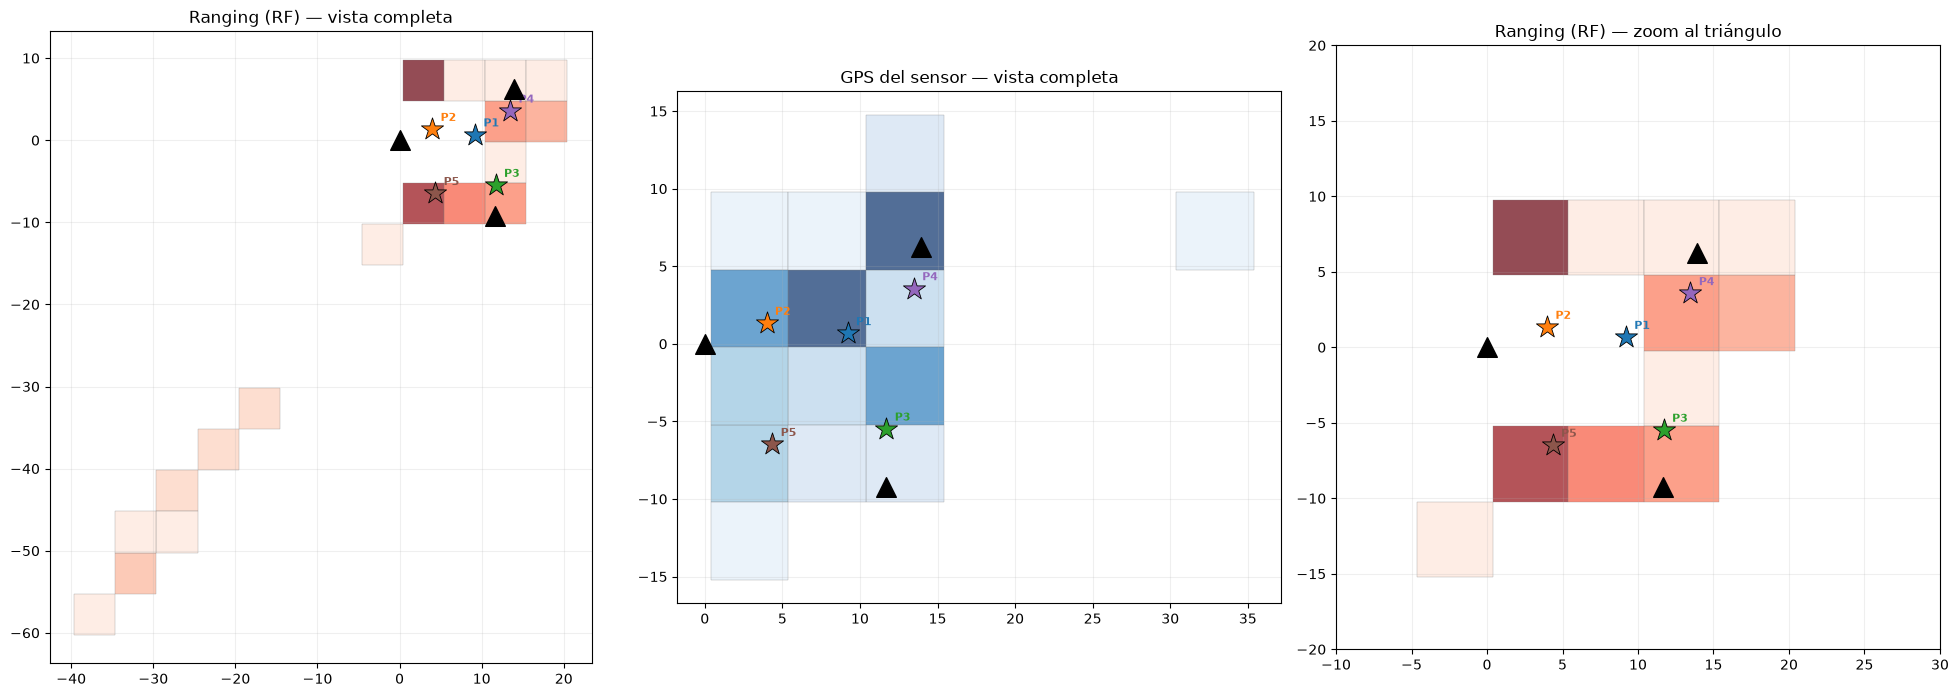

In [58]:
colores_punto = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:green', 4: 'tab:purple', 5: 'tab:brown'}

def pintar_zonas(ax, df_zonas, origen, cmap='Reds'):
    sub = df_zonas[df_zonas['origen_posicion'] == origen]
    max_n = sub['n_fijaciones'].max()
    for _, z in sub.iterrows():
        x_min, y_min = proyectar_xy(z['lat_min'], z['lon_min'], lat_ref, lon_ref)
        x_max, y_max = proyectar_xy(z['lat_max'], z['lon_max'], lat_ref, lon_ref)
        color_intensidad = z['n_fijaciones'] / max_n
        ax.add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, color=plt.get_cmap(cmap)(color_intensidad), alpha=0.7, ec='gray', lw=0.3))

def pintar_puntos_referencia(ax):
    for _, p in referencia.iterrows():
        punto = int(p['punto'])
        ax.scatter(p['x_real'], p['y_real'], marker='*', s=280, color=colores_punto[punto], edgecolor='black', linewidth=0.6, zorder=6)
        ax.annotate(f'P{punto}', (p['x_real'], p['y_real']), textcoords='offset points', xytext=(6, 6), fontsize=8, fontweight='bold', color=colores_punto[punto])

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

configs = [
    ('ranging', 'Reds', 'Ranging (RF) — vista completa', None),
    ('gps', 'Blues', 'GPS del sensor — vista completa', None),
    ('ranging', 'Reds', 'Ranging (RF) — zoom al triángulo', (-10, 30, -20, 20)),
]

for ax, (origen, cmap, titulo, zoom) in zip(axes, configs):
    pintar_zonas(ax, zonas_ocupacion, origen, cmap)
    ax.scatter(anclas['x'], anclas['y'], marker='^', s=200, color='black', zorder=5)
    pintar_puntos_referencia(ax)
    ax.set_title(titulo)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    if zoom:
        x_min, x_max, y_min, y_max = zoom
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()